In [2]:
import numpy as np
import matplotlib.pyplot as plt

import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
from Analyze_Observable import analyze_observable, plot_phase_diagram
%load_ext autoreload
%autoreload 2

Monte Carlo Sweeps: 100%|██████████| 200000/200000 [00:00<00:00, 495378.92it/s]


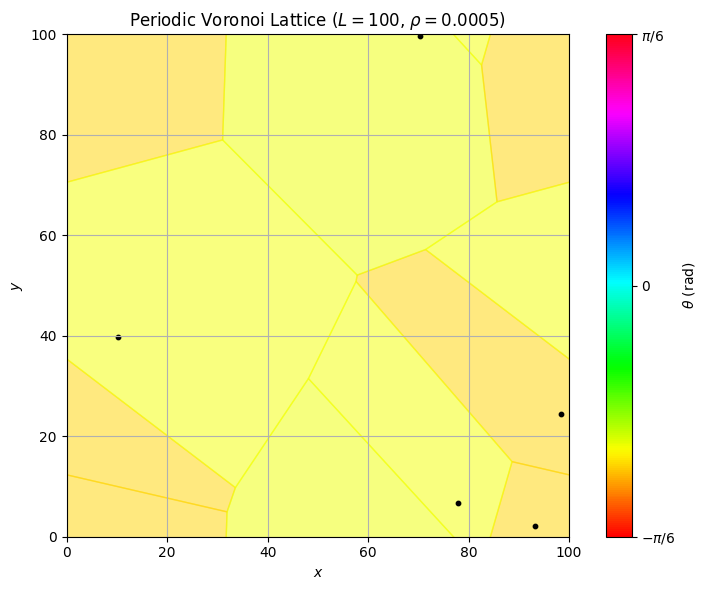

Iteration 1, max displacement: 99.987559, time: 0.20 s
Iteration 2, max displacement: 0.215190, time: 0.19 s
Iteration 3, max displacement: 0.157706, time: 0.33 s
Iteration 4, max displacement: 0.119009, time: 0.18 s
Iteration 5, max displacement: 0.092895, time: 0.31 s
Iteration 6, max displacement: 99.978154, time: 0.17 s
Iteration 7, max displacement: 0.062401, time: 0.18 s
Iteration 8, max displacement: 0.052750, time: 0.30 s
Iteration 9, max displacement: 0.046062, time: 0.18 s
Iteration 10, max displacement: 0.045745, time: 0.17 s
Iteration 11, max displacement: 0.044980, time: 0.29 s
Iteration 12, max displacement: 0.043021, time: 0.16 s
Iteration 13, max displacement: 0.040122, time: 0.30 s
Iteration 14, max displacement: 0.036611, time: 0.17 s
Iteration 15, max displacement: 0.037962, time: 0.17 s
Iteration 16, max displacement: 0.039131, time: 0.30 s
Iteration 17, max displacement: 0.040028, time: 0.17 s
Iteration 18, max displacement: 0.040813, time: 0.30 s
Iteration 19, max

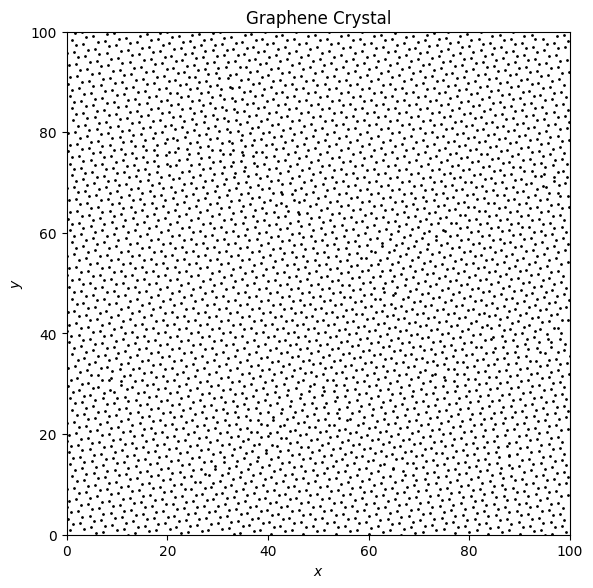

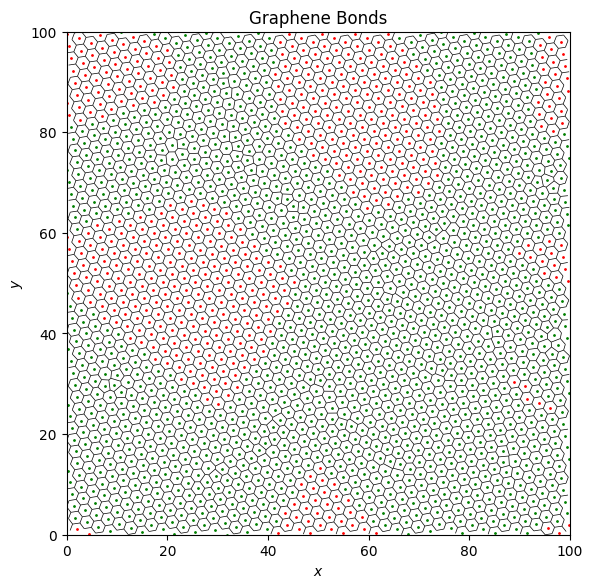

In [7]:
L = 100
rho = 0.0005

T = 4
alpha = 2.36
beta_RS = -0.12
epsilon = 0

vor = Voronoi.PeriodicVoronoi(L, rho)

thetas, energy = MonteCarlo.monte_carlo(vor.theta, vor.adj_i, vor.adj_j, vor.adj_length, 1/T, epsilon, rho, alpha, beta_RS, 200_000)
vor.theta = thetas
vor.plot()
plt.show()

graphene = Graphene.GrapheneCrystal(vor, a = 1.42)

# graphene.save_crystal('results/graphene_test.npz')

graphene.plot_atoms()
plt.show()
graphene.plot_bonds()
plt.show()

In [5]:
epsilon = 0.5
L = 150
rho = 0.004

analyze_observable(L, epsilon, rho)

In [ ]:
phase_data = {
    0: {
        0.0005: {
            "T" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
            "phases" : ["s", "s", "s", "s", "s", "s", "s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l"]
        },
        0.002: {
            "T" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            "phases" : ["s", "s", "s", "h", "h", "h", "l", "l", "l", "l"]
        },
        0.004: {
            "T" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            "phases" : ["s", "s", "s", "h", "l", "l", "l", "l", "l", "l"]
        }
    },
    0.5: {
        0.002: {
            "T" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 17, 25, 30],
            "phases" : ["s", "s", "s", "s", "s", "s", "s", "s", "s", "h", "h", "l", "l", "l"]
        },
        0.004: {
            "T" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
            "phases" : ["s", "s", "s", "s", "s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l"]
        }
    }
}

plot_phase_diagram_3d(phase_data)